In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


house_df_org = pd.read_csv('../data/house_price.csv')
house_df = house_df_org.copy()  # 원본 보호
house_df.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [2]:
# 전체 데이터 구조 파악
print(f"데이터 세트의 Shape : {house_df.shape}")
print(f"피처의 데이터 타입 개수:\n {house_df.dtypes.value_counts()}")

데이터 세트의 Shape : (1460, 81)
피처의 데이터 타입 개수:
 str        43
int64      35
float64     3
Name: count, dtype: int64


In [3]:
# 피처의 Null 개수 확인
isnull_series = house_df.isna().sum()
isnull_series[isnull_series>0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

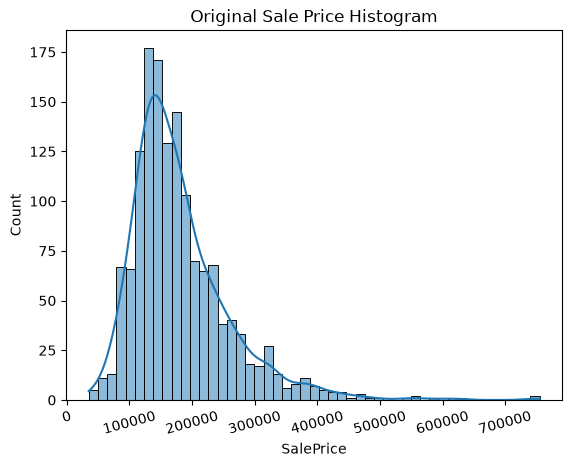

In [4]:
# Label 분포 확인
plt.title("Original Sale Price Histogram")
plt.xticks(rotation=15)
sns.histplot(house_df["SalePrice"], kde=True)
plt.show()

In [5]:
# SalePrice 로그 변환
original_SalePrice = house_df['SalePrice']  # 원래 가격을 임시 저장
house_df['SalePrice'] = np.log1p(house_df['SalePrice']) # 로그 변환


# Null 이 너무 많은 컬럼들과 불필요한 컬럼 삭제
house_df.drop(['Id','PoolQC' , 'MiscFeature', 'Alley', 'Fence','FireplaceQu'], axis=1 , inplace=True)


In [6]:

# Drop 하지 않는 숫자형 Null컬럼들은 평균값으로 대체
# house_df.fillna(house_df.mean(),inplace=True)
# dtype : str 인 피처는 평균을 못 구한다.
# dtype이 str인 피처를 제외하고 평균으로 채워라
# 숫자 타입 피처 추출
num_columns = house_df.dtypes[house_df.dtypes != 'str'].index.to_list()
house_df[num_columns] = house_df[num_columns].fillna(house_df[num_columns].mean())
# Null 값이 있는 피처명과 타입을 추출
null_column_count = house_df.isnull().sum()[house_df.isnull().sum() > 0]
print('## Null 피처의 Type :\n', house_df.dtypes[null_column_count.index])


## Null 피처의 Type :
 MasVnrType      str
BsmtQual        str
BsmtCond        str
BsmtExposure    str
BsmtFinType1    str
BsmtFinType2    str
Electrical      str
GarageType      str
GarageFinish    str
GarageQual      str
GarageCond      str
dtype: object


In [7]:
house_df = house_df_org.copy() # 원본 보호
# SalePrice 로그 변환
original_SalePrice = house_df['SalePrice'] # 원래 가격을 임시 저장
house_df['SalePrice'] = np.log1p(house_df['SalePrice']) # 로그 변환


# Null 이 너무 많은 컬럼들과 불필요한 컬럼 삭제
house_df.drop(['Id','PoolQC' , 'MiscFeature', 'Alley', 'Fence','FireplaceQu'], axis=1 , inplace=True)
# Drop 하지 않는 숫자형 Null컬럼들은 평균값으로 대체
# house_df.fillna(house_df.mean(),inplace=True)
house_df[num_columns] = house_df[num_columns].fillna(house_df[num_columns].mean())


# Null 값이 있는 피처명과 타입을 추출
null_column_count = house_df.isnull().sum()[house_df.isnull().sum() > 0]
print('## Null 피처의 Type :\n', house_df.dtypes[null_column_count.index])


## Null 피처의 Type :
 MasVnrType      str
BsmtQual        str
BsmtCond        str
BsmtExposure    str
BsmtFinType1    str
BsmtFinType2    str
Electrical      str
GarageType      str
GarageFinish    str
GarageQual      str
GarageCond      str
dtype: object


In [8]:
house_df[num_columns].head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,12.247699
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,12.109016
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,12.317171
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,11.849405
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,12.429220


In [9]:
house_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 75 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1460 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   LotShape       1460 non-null   str    
 6   LandContour    1460 non-null   str    
 7   Utilities      1460 non-null   str    
 8   LotConfig      1460 non-null   str    
 9   LandSlope      1460 non-null   str    
 10  Neighborhood   1460 non-null   str    
 11  Condition1     1460 non-null   str    
 12  Condition2     1460 non-null   str    
 13  BldgType       1460 non-null   str    
 14  HouseStyle     1460 non-null   str    
 15  OverallQual    1460 non-null   int64  
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-null   int64  
 18  YearRemodAdd   1460

In [10]:
# 문자열 타입의 NaN 개수 : NaN 발생하는 경우 언제? => 계산할 때. str은 계산x
# house_df.isna().sum()   # 피처별 NaN 개수 -> 시리즈
num_columns = house_df.isna().sum()[house_df.isna().sum()>0]  # Series라 boolean indexing 가능
num_columns

MasVnrType      872
BsmtQual         37
BsmtCond         37
BsmtExposure     38
BsmtFinType1     37
BsmtFinType2     38
Electrical        1
GarageType       81
GarageFinish     81
GarageQual       81
GarageCond       81
dtype: int64

In [11]:
house_df.dtypes.value_counts()

str        38
int64      33
float64     4
Name: count, dtype: int64

In [12]:
# 원핫
print(f"원핫하기 전 데이터프레임 구조: {house_df.shape}")

원핫하기 전 데이터프레임 구조: (1460, 75)


In [13]:
# get_dummies(dataframe): 카테고리 컬럼 원핫 처리. 
# 현장에서는 모르는 컬럼 원핫처리하면 안 됨. 카테고리가 아닌 컬럼이 있을 수도, 카테고리가 나중에는 아니게 되기도 함.(예. 연도)
# 꼼꼼하게 컬럼들 확인 후 get_dummies()
house_df_ohe = pd.get_dummies(house_df)
print(f"원핫 후 구조: {house_df_ohe.shape}")


원핫 후 구조: (1460, 270)


In [14]:
house_df_ohe.head(3)

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,False,False,False,True,False,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,False,False,False,True,False,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,False,False,False,True,False,False,False,False,True,False


In [15]:
# null 피처를 확인
null_column_count = house_df_ohe.isna().sum()[house_df_ohe.isna().sum()>0]
print(null_column_count)

Series([], dtype: int64)


In [16]:
# RMSLE, SalePrice 로그 변환한 상태
from sklearn.metrics import mean_squared_error

# 오차: 원래답 - 예측값
def get_rmse(model, X_test=None, y_test=None): # model.fit 된 모델
    pred = model.predict(X_test) # X_test 밖에 있는 놈 가져다 쓰겠다 <= 하지마세요, 받어서 쓰게 하세요
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    print(f'{model.__class__.__name__} : 로그 변환된 RMSE : {rmse:.3f}') # model object <= new class
    return rmse
 

In [17]:
def get_rmses(models, X_test=None, y_test=None): # fitting
    rmses = []
    for model in models:
        rmse = get_rmse(model, X_test, y_test)
        rmses.append(rmse)
    return rmses


In [18]:
# 데이터/답 분리, 학습/테스트 데이터 분리
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


y_target = house_df_ohe['SalePrice']
X_features = house_df_ohe.drop('SalePrice', axis=1) # , inplace=False  default가 False


X_train, X_test, y_train, y_test = train_test_split(
    X_features,
    y_target,
    test_size=0.2,
    random_state=156
)


In [19]:
# 회귀 모델 학습/성능 평가
lr_reg = LinearRegression()
lr_reg.fit(X_train,y_train)
ridge_reg = Ridge()
ridge_reg.fit(X_train,y_train)
lasso_reg = Lasso()
lasso_reg.fit(X_train, y_train)


models = [lr_reg, ridge_reg, lasso_reg]
get_rmses(models, X_test, y_test)

#Lasso. 조금이라도 영향 가는 피처의 회귀계수가 0에 가까워서 지워버림 -> rmse 더 오름.

LinearRegression : 로그 변환된 RMSE : 0.133
Ridge : 로그 변환된 RMSE : 0.127
Lasso : 로그 변환된 RMSE : 0.176


[np.float64(0.13311192570011496),
 np.float64(0.1274058283626635),
 np.float64(0.17628250556471411)]

In [20]:
# Model object : coef_(계수), intercept_(절편)
def get_top_bottom_coef(model, n=10):
    coef = pd.Series(model.coef_, index=X_features.columns)
    coef_high = coef.sort_values(ascending=False).head(n)
    coef_low = coef.sort_values(ascending=False).tail(n)
    return coef_high, coef_low


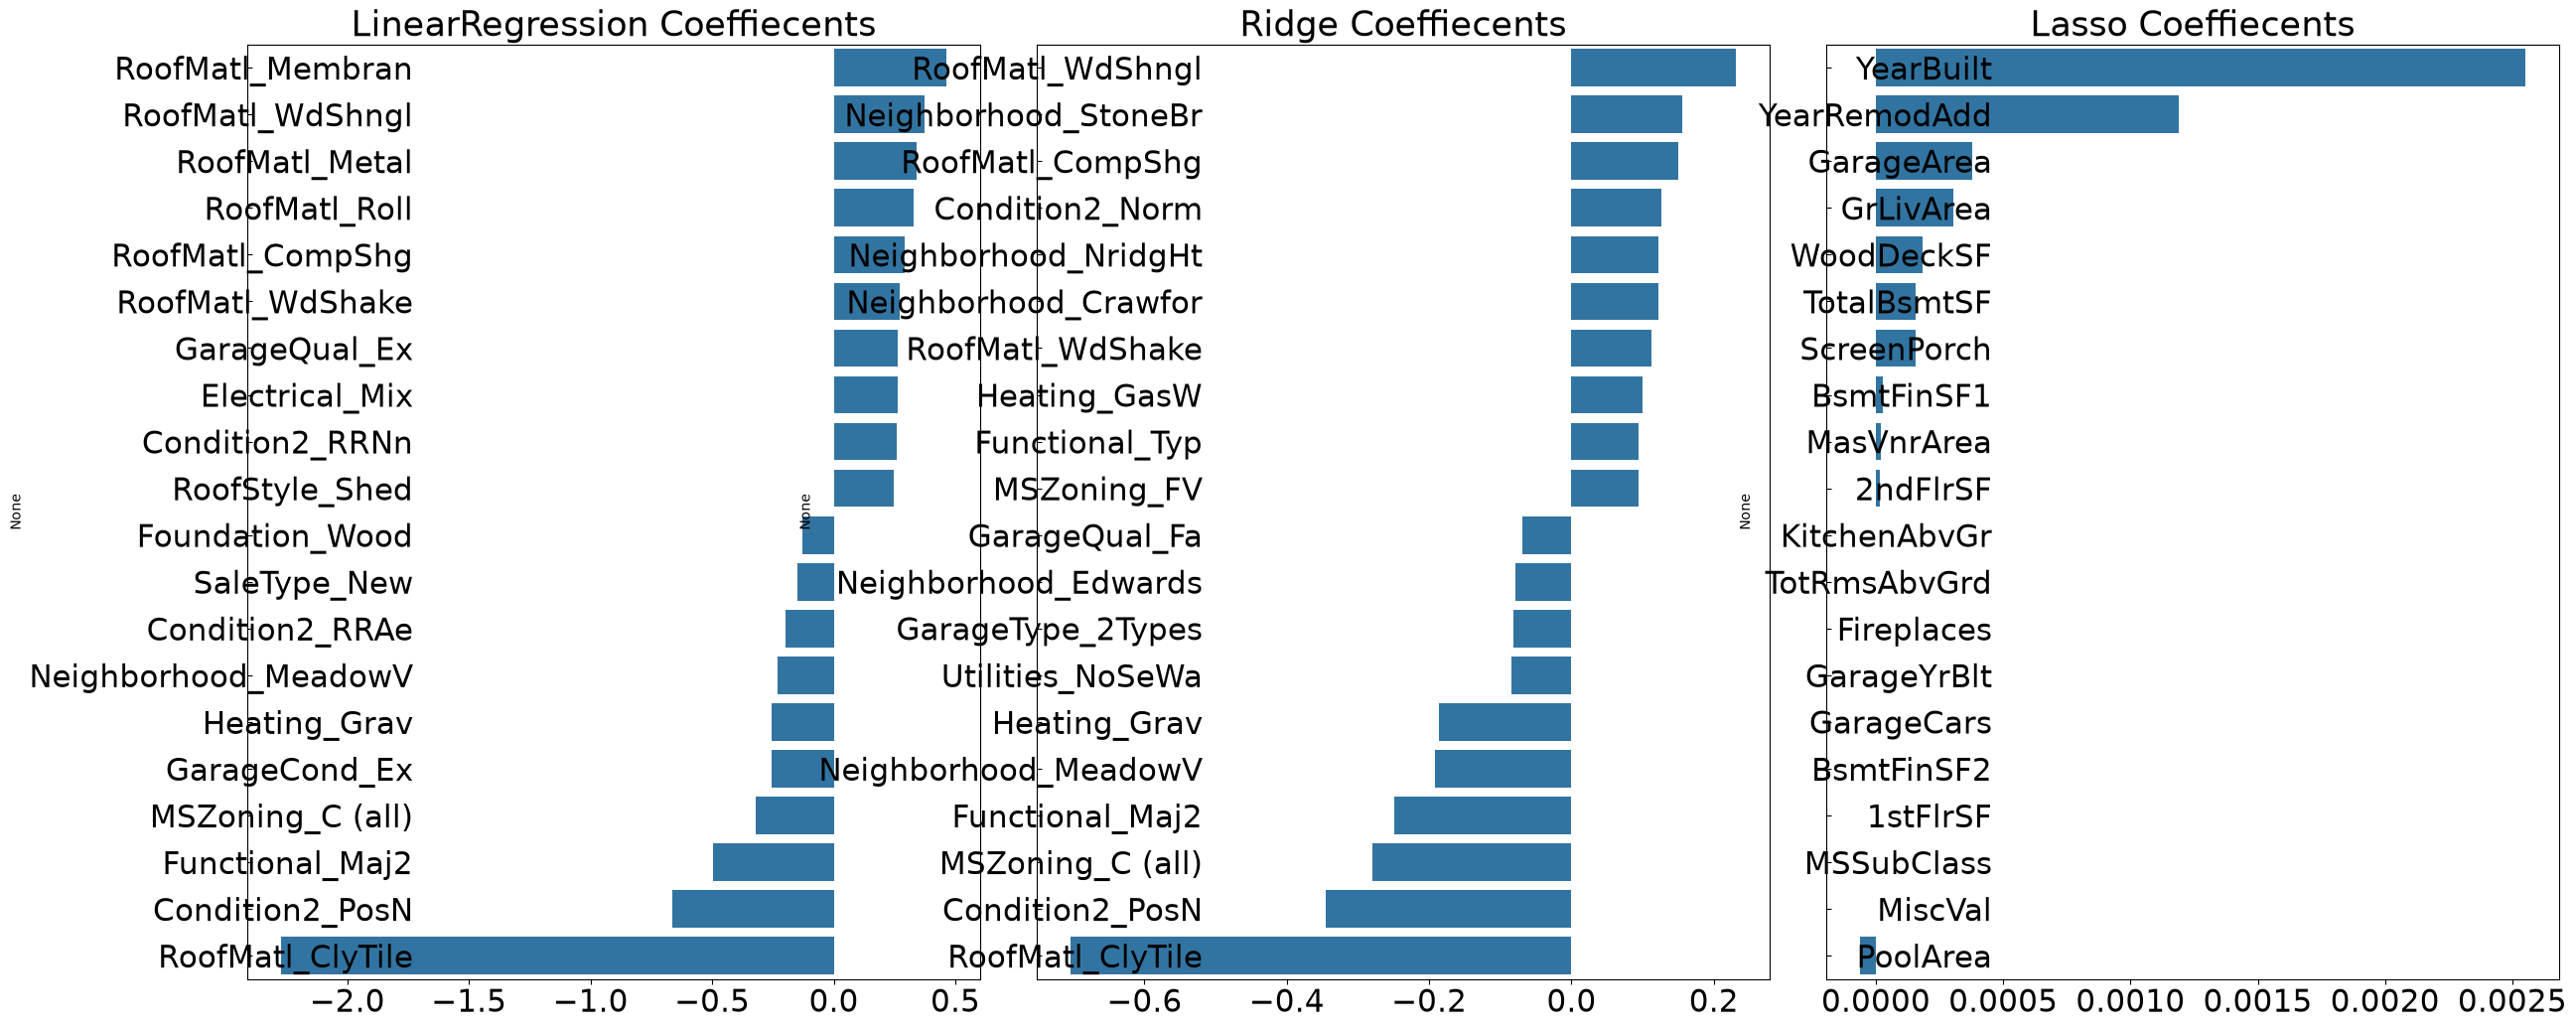

In [21]:
def visualize_coefficient(models):
    # 3개 회귀 모델의 시각화를 위해 3개의 컬럼을 가지는 subplot 생성
    fig, axs = plt.subplots(figsize=(24,10),nrows=1, ncols=3)
    fig.tight_layout()
    # 입력인자로 받은 list객체인 models에서 차례로 model을 추출하여 회귀 계수 시각화.
    for i_num, model in enumerate(models):
        # 상위 10개, 하위 10개 회귀 계수를 구하고, 이를 판다스 concat으로 결합.
        coef_high, coef_low = get_top_bottom_coef(model)
        coef_concat = pd.concat( [coef_high , coef_low] )
        # 순차적으로 ax subplot에 barchar로 표현. 한 화면에 표현하기 위해 tick label 위치와 font 크기 조정.
        axs[i_num].set_title(model.__class__.__name__+' Coeffiecents', size=25)
        axs[i_num].tick_params(axis="y",direction="in", pad=-120)
        for label in (axs[i_num].get_xticklabels() + axs[i_num].get_yticklabels()):
            label.set_fontsize(22)
        sns.barplot(x=coef_concat.values, y=coef_concat.index , ax=axs[i_num])


# 앞 예제에서 학습한 lr_reg, ridge_reg, lasso_reg 모델의 회귀 계수 시각화.    
models = [lr_reg, ridge_reg, lasso_reg]
visualize_coefficient(models)
# 그래프에서 Ridge 큰 값 작게 바뀐 것 확인
# 그래프에서 Lasso 값 지워진 것 확인 w1*x1 인데 w1=0이면 x1 삭제됨.

In [22]:
# Cross_validation
from sklearn.model_selection import cross_val_score


def get_avg_rmse_cv(models):
    for model in models:
        # 분할하지 않고 전체 데이터로 cross_val_score( ) 수행. 모델별 CV RMSE값과 평균 RMSE 출력
        rmse_list = np.sqrt(-1 * cross_val_score(model, X_features, y_target,
                                             scoring="neg_mean_squared_error", cv = 5))
        rmse_avg = np.mean(rmse_list)
        print('\n{0} CV RMSE 값 리스트: {1}'.format( model.__class__.__name__, np.round(rmse_list, 3)))
        print('{0} CV 평균 RMSE 값: {1}'.format( model.__class__.__name__, np.round(rmse_avg, 3)))


# 앞 예제에서 학습한 lr_reg, ridge_reg, lasso_reg 모델의 CV RMSE값 출력          
models = [lr_reg, ridge_reg, lasso_reg]
get_avg_rmse_cv(models)



LinearRegression CV RMSE 값 리스트: [0.135 0.165 0.172 0.112 0.198]
LinearRegression CV 평균 RMSE 값: 0.156

Ridge CV RMSE 값 리스트: [0.117 0.154 0.142 0.117 0.189]
Ridge CV 평균 RMSE 값: 0.144

Lasso CV RMSE 값 리스트: [0.161 0.204 0.177 0.181 0.265]
Lasso CV 평균 RMSE 값: 0.198


In [23]:
from sklearn.model_selection import GridSearchCV


def print_best_params(model, params):
    grid_model = GridSearchCV(model, param_grid=params,
                              scoring='neg_mean_squared_error', cv=5)
    grid_model.fit(X_features, y_target)
    rmse = np.sqrt(-1* grid_model.best_score_)
    print('{0} 5 CV 시 최적 평균 RMSE 값: {1}, 최적 alpha:{2}'.format(model.__class__.__name__,
                                        np.round(rmse, 4), grid_model.best_params_))
    return grid_model.best_estimator_


ridge_params = { 'alpha':[0.05, 0.1, 1, 5, 8, 10, 12, 15, 20] }
lasso_params = { 'alpha':[0.001, 0.005, 0.008, 0.05, 0.03, 0.1, 0.5, 1,5, 10] }
best_rige = print_best_params(ridge_reg, ridge_params)
best_lasso = print_best_params(lasso_reg, lasso_params)

# 튜닝하니 Ridge, Lasso 비슷해짐.

Ridge 5 CV 시 최적 평균 RMSE 값: 0.1418, 최적 alpha:{'alpha': 12}
Lasso 5 CV 시 최적 평균 RMSE 값: 0.142, 최적 alpha:{'alpha': 0.001}


In [24]:
from scipy.stats import skew
# dtypes : Series => index 가 컬럼명.
number_columns = house_df.dtypes[house_df.dtypes != 'str'].index
skew_features = house_df[number_columns].apply(lambda x: skew(x))  # x: 각 컬럼을 받는다. 컬럼별 왜도 반환.
# skew_festures : 숫자형 컬럼의 왜도 값.
skew_features_top = skew_features[skew_features>1].sort_values(ascending=False)
skew_features_top

MiscVal          24.451640
PoolArea         14.813135
LotArea          12.195142
3SsnPorch        10.293752
LowQualFinSF      9.002080
KitchenAbvGr      4.483784
BsmtFinSF2        4.250888
ScreenPorch       4.117977
BsmtHalfBath      4.099186
EnclosedPorch     3.086696
MasVnrArea        2.673661
LotFrontage       2.382499
OpenPorchSF       2.361912
BsmtFinSF1        1.683771
WoodDeckSF        1.539792
TotalBsmtSF       1.522688
MSSubClass        1.406210
1stFlrSF          1.375342
GrLivArea         1.365156
dtype: float64

In [25]:
# 로그 변환
np.log1p(house_df[skew_features_top.index])

,MiscVal,PoolArea,LotArea,3SsnPorch,LowQualFinSF,KitchenAbvGr,BsmtFinSF2,ScreenPorch,BsmtHalfBath,EnclosedPorch,MasVnrArea,LotFrontage,OpenPorchSF,BsmtFinSF1,WoodDeckSF,TotalBsmtSF,MSSubClass,1stFlrSF,GrLivArea
0,0.000000,0.0,9.042040,0.0,0.0,0.693147,0.000000,0.0,0.000000,0.000000,5.283204,4.189655,4.127134,6.561031,0.000000,6.753438,4.110874,6.753438,7.444833
1,0.000000,0.0,9.169623,0.0,0.0,0.693147,0.000000,0.0,0.693147,0.000000,0.000000,4.394449,0.000000,6.886532,5.700444,7.141245,3.044522,7.141245,7.141245
2,0.000000,0.0,9.328212,0.0,0.0,0.693147,0.000000,0.0,0.000000,0.000000,5.093750,4.234107,3.761200,6.188264,0.000000,6.825460,4.110874,6.825460,7.488294
3,0.000000,0.0,9.164401,0.0,0.0,0.693147,0.000000,0.0,0.000000,5.609472,0.000000,4.110874,3.583519,5.379897,0.000000,6.629363,4.262680,6.869014,7.448916
4,0.000000,0.0,9.565284,0.0,0.0,0.693147,0.000000,0.0,0.000000,0.000000,5.860786,4.442651,4.442651,6.486161,5.262690,7.044033,4.110874,7.044033,7.695758
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,0.000000,0.0,8.976894,0.0,0.0,0.693147,0.000000,0.0,0.000000,0.000000,0.000000,4.143135,3.713572,0.000000,0.000000,6.860664,4.110874,6.860664,7.407318
1456,0.000000,0.0,9.486152,0.0,0.0,0.693147,5.099866,0.0,0.000000,0.000000,4.787492,4.454347,0.000000,6.673298,5.857933,7.341484,3.044522,7.637234,7.637234
1457,7.824446,0.0,9.109746,0.0,0.0,0.693147,0.000000,0.0,0.000000,0.000000,0.000000,4.204693,4.110874,5.620401,0.000000,7.050123,4.262680,7.080868,7.758333
1458,0.000000,0.0,9.181735,0.0,0.0,0.693147,6.937314,0.0,0.000000,4.727388,0.000000,4.234107,0.000000,3.912023,5.905362,6.983790,3.044522,6.983790,6.983790


In [26]:
# 왜도 1보다 큰 컬럼들 확인: 대칭이 아니다.
house_df[skew_features_top.index]

,MiscVal,PoolArea,LotArea,3SsnPorch,LowQualFinSF,KitchenAbvGr,BsmtFinSF2,ScreenPorch,BsmtHalfBath,EnclosedPorch,MasVnrArea,LotFrontage,OpenPorchSF,BsmtFinSF1,WoodDeckSF,TotalBsmtSF,MSSubClass,1stFlrSF,GrLivArea
0,0,0,8450,0,0,1,0,0,0,0,196.0,65.0,61,706,0,856,60,856,1710
1,0,0,9600,0,0,1,0,0,1,0,0.0,80.0,0,978,298,1262,20,1262,1262
2,0,0,11250,0,0,1,0,0,0,0,162.0,68.0,42,486,0,920,60,920,1786
3,0,0,9550,0,0,1,0,0,0,272,0.0,60.0,35,216,0,756,70,961,1717
4,0,0,14260,0,0,1,0,0,0,0,350.0,84.0,84,655,192,1145,60,1145,2198
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,0,0,7917,0,0,1,0,0,0,0,0.0,62.0,40,0,0,953,60,953,1647
1456,0,0,13175,0,0,1,163,0,0,0,119.0,85.0,0,790,349,1542,20,2073,2073
1457,2500,0,9042,0,0,1,0,0,0,0,0.0,66.0,60,275,0,1152,70,1188,2340
1458,0,0,9717,0,0,1,1029,0,0,112,0.0,68.0,0,49,366,1078,20,1078,1078


<Axes: xlabel='GrLivArea', ylabel='Count'>

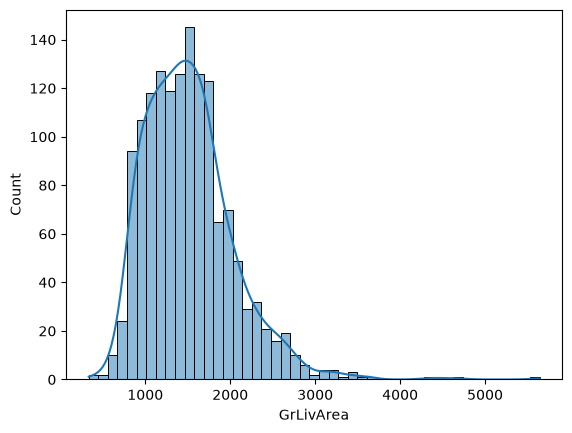

In [27]:
sns.histplot(house_df["GrLivArea"], kde=True)

<Axes: xlabel='GrLivArea', ylabel='Count'>

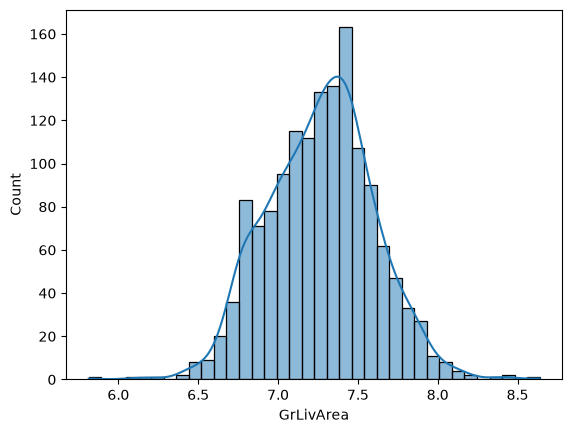

In [28]:
house_df[skew_features_top.index] = np.log1p(house_df[skew_features_top.index])
sns.histplot(house_df["GrLivArea"], kde=True)

In [29]:
# house_df => house_df_ohe
house_df_ohe = pd.get_dummies(house_df)


y_target = house_df_ohe['SalePrice']
X_features = house_df_ohe.drop('SalePrice',axis=1, inplace=False)
X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.2, random_state=156)


# 피처들을 로그 변환 후 다시 최적 하이퍼 파라미터와 RMSE 출력
ridge_params = { 'alpha':[0.05, 0.1, 1, 5, 8, 10, 12, 15, 20] }
lasso_params = { 'alpha':[0.001, 0.005, 0.008, 0.05, 0.03, 0.1, 0.5, 1,5, 10] }
best_ridge = print_best_params(ridge_reg, ridge_params)
best_lasso = print_best_params(lasso_reg, lasso_params)


KeyboardInterrupt: 

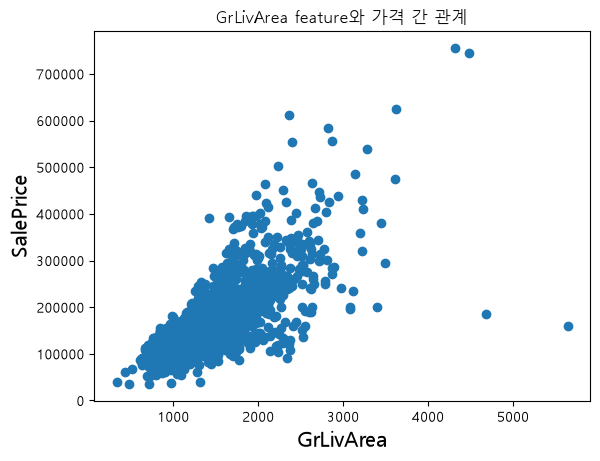

In [ ]:
# GrLivArea와 SalePrice 관계 시각화: 산점도(scatter)
import matplotlib.pyplot as plt
plt.scatter(
    x=house_df_org["GrLivArea"],
    y=house_df_org["SalePrice"]
)
plt.ylabel("SalePrice", fontsize=15)
plt.xlabel("GrLivArea", fontsize=15)
plt.title("GrLivArea feature와 가격 간 관계")
plt.show()

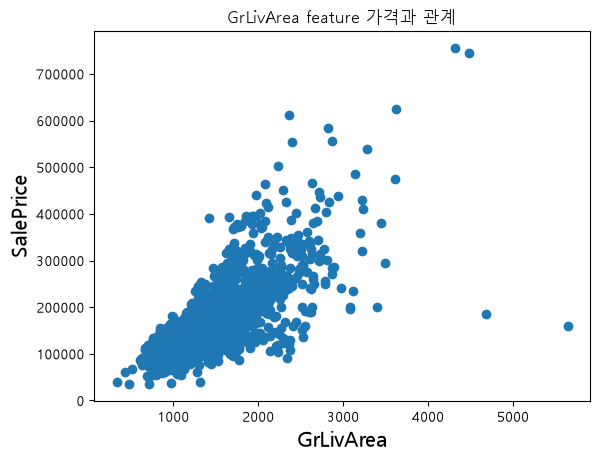

In [ ]:
# GrLivArea왜 SalePrice 관계 시각화 : 산점도(scatter)
import matplotlib.pyplot as plt
from matplotlib import rcParams


rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 기본 한글 폰트(맑은 고딕)
rcParams['axes.unicode_minus'] = False      # 마이너스 부호 깨짐 방지


plt.scatter(
    x=house_df_org['GrLivArea'],
    y=house_df_org['SalePrice']
)
plt.ylabel('SalePrice', fontsize=15)
plt.xlabel('GrLivArea', fontsize=15)
plt.title('GrLivArea feature 가격과 관계')
plt.show()


In [ ]:
# 이상치
cond1 = house_df_ohe['GrLivArea'] > np.log1p(4000)
cond2 = house_df_ohe['SalePrice'] < np.log1p(500000)
outlier_index = house_df_ohe[cond1 & cond2].index
outlier_index


RangeIndex(start=523, stop=2073, step=775)

In [ ]:
house_df_ohe.drop(outlier_index, axis=0, inplace=True)
print(house_df_ohe.shape)

(1458, 270)


In [ ]:
y_target = house_df_ohe['SalePrice']
X_features = house_df_ohe.drop('SalePrice',axis=1, inplace=False)
X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.2, random_state=156)


ridge_params = { 'alpha':[0.05, 0.1, 1, 5, 8, 10, 12, 15, 20] }
lasso_params = { 'alpha':[0.001, 0.005, 0.008, 0.05, 0.03, 0.1, 0.5, 1,5, 10] }
best_ridge = print_best_params(ridge_reg, ridge_params)
best_lasso = print_best_params(lasso_reg, lasso_params)

# 회귀계수 높은 데이터 중 이상치 2개 제거 -> 8% 성능 향상

Ridge 5 CV 시 최적 평균 RMSE 값: 0.1125, 최적 alpha:{'alpha': 8}
Lasso 5 CV 시 최적 평균 RMSE 값: 0.1122, 최적 alpha:{'alpha': 0.001}


In [ ]:
# 회귀 트리 : XGB, LGBM
from xgboost import XGBRegressor


xgb_params = {'n_estimators':[1000]}
xgb_reg = XGBRegressor(n_estimators=1000, learning_rate=0.05, colsample_bytree=0.5, subsample=0.8)
best_xgb = print_best_params(xgb_reg, xgb_params)

XGBRegressor 5 CV 시 최적 평균 RMSE 값: 0.1191, 최적 alpha:{'n_estimators': 1000}


In [ ]:
from lightgbm import LGBMRegressor


lgbm_params = {'n_estimators':[1000]}
lgbm_reg = LGBMRegressor(n_estimators=1000, learning_rate=0.05, num_leaves=4,
                         subsample=0.6, colsample_bytree=0.4, reg_lambda=10, n_jobs=-1)
best_lgbm = print_best_params(lgbm_reg, lgbm_params)
best_lgbm

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001415 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3155
[LightGBM] [Info] Number of data points in the train set: 1166, number of used features: 171
[LightGBM] [Info] Start training from score 12.021352
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001212 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3167
[LightGBM] [Info] Number of data points in the train set: 1166, number of used features: 168
[LightGBM] [Info] Start training from score 12.023516
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of 

,num_leaves,4
,learning_rate,0.05
,n_estimators,1000
,subsample,0.6
,colsample_bytree,0.4
,reg_lambda,10
,n_jobs,-1
,boosting_type,'gbdt'
,max_depth,-1
,subsample_for_bin,200000
,objective,None


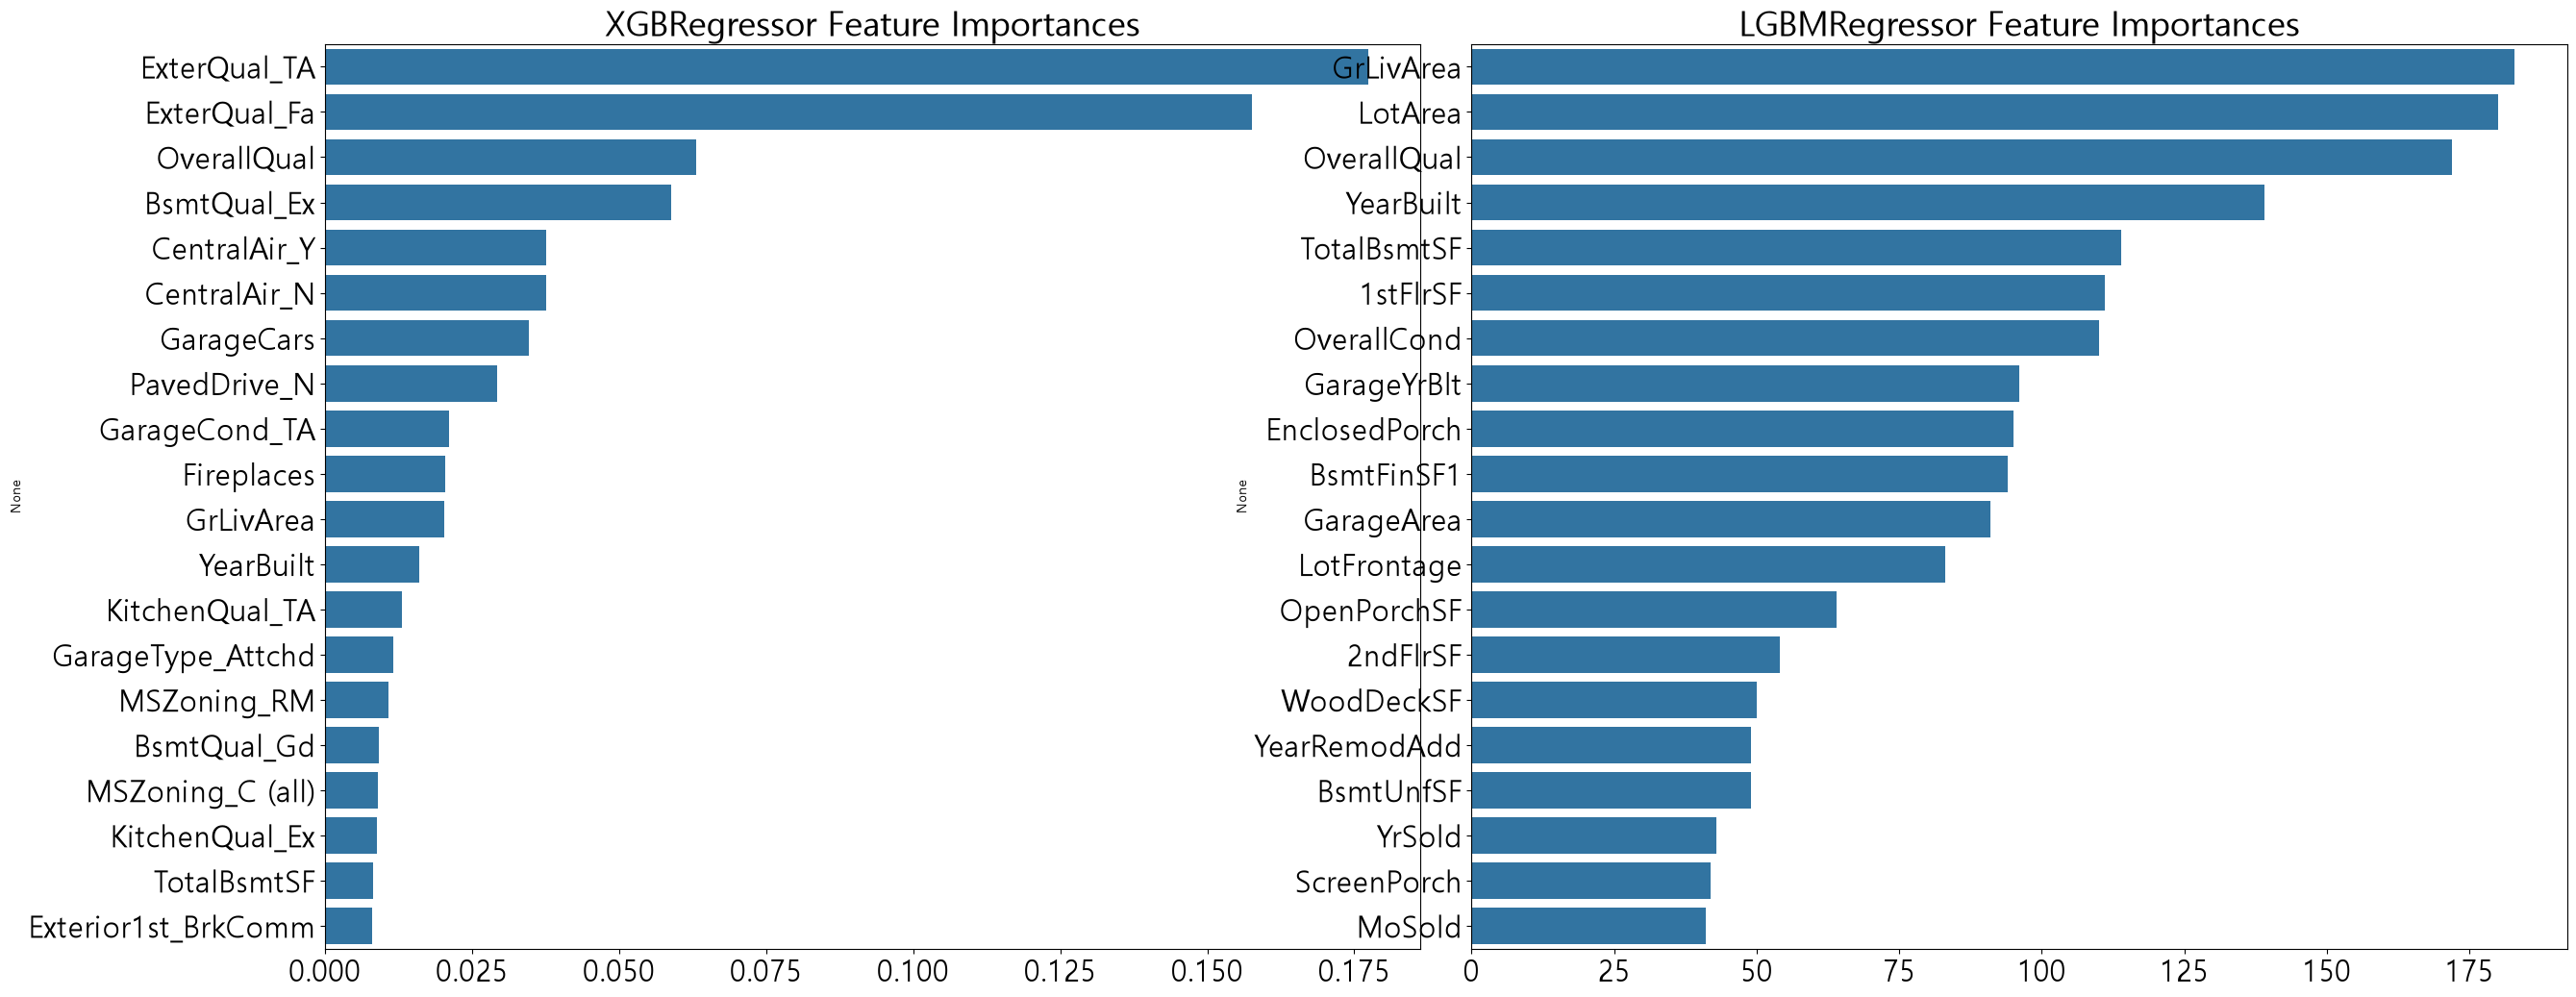

In [ ]:
# 모델의 중요도 상위 20개의 피처명과 그때의 중요도값을 Series로 반환.
def get_top_features(model):
    ftr_importances_values = model.feature_importances_
    ftr_importances = pd.Series(ftr_importances_values, index=X_features.columns  )
    ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]
    return ftr_top20


def visualize_ftr_importances(models):
    # 2개 회귀 모델의 시각화를 위해 2개의 컬럼을 가지는 subplot 생성
    fig, axs = plt.subplots(figsize=(24,10),nrows=1, ncols=2)
    fig.tight_layout()
    # 입력인자로 받은 list객체인 models에서 차례로 model을 추출하여 피처 중요도 시각화.
    for i_num, model in enumerate(models):
        # 중요도 상위 20개의 피처명과 그때의 중요도값 추출
        ftr_top20 = get_top_features(model)
        axs[i_num].set_title(model.__class__.__name__+' Feature Importances', size=25)
        #font 크기 조정.
        for label in (axs[i_num].get_xticklabels() + axs[i_num].get_yticklabels()):
            label.set_fontsize(22)
        sns.barplot(x=ftr_top20.values, y=ftr_top20.index , ax=axs[i_num])


# 앞 예제에서 print_best_params( )가 반환한 GridSearchCV로 최적화된 모델의 피처 중요도 시각화    
models = [best_xgb, best_lgbm]
visualize_ftr_importances(models)


In [ ]:
def get_rmse_pred(preds):
    for key in preds.keys():
        pred_value = preds[key]
        mse = mean_squared_error(y_test, pred_value)
        rmse = np.sqrt(mse)
        print(f'{key} 모델의 RMSE : {rmse}')


In [ ]:
ridge_reg = Ridge(alpha=8)
ridge_reg.fit(X_train, y_train)
lasso_reg = Lasso(alpha=0.001)
lasso_reg.fit(X_train, y_train)


# 개별 모델의 예측 추출
ridge_pred = ridge_reg.predict(X_test)
lasso_pred = lasso_reg.predict(X_test)


# 혼합
pred = 0.4 * ridge_pred + 0.6 * lasso_pred


preds = {
    '최종 혼합' : pred,
    'Ridge' : ridge_pred,
    'Lasso' : lasso_pred
}


get_rmse_pred(preds)


최종 혼합 모델의 RMSE : 0.10006075517615197
Ridge 모델의 RMSE : 0.10340697165289382
Lasso 모델의 RMSE : 0.10024171179335334


In [ ]:
xgb_reg = XGBRegressor(n_estimators=1000, learning_rate=0.05,
                       colsample_bytree=0.5, subsample=0.8)
lgbm_reg = LGBMRegressor(n_estimators=1000, learning_rate=0.05, num_leaves=4,
                         subsample=0.6, colsample_bytree=0.4, reg_lambda=10, n_jobs=-1)
xgb_reg.fit(X_train, y_train)
lgbm_reg.fit(X_train, y_train)
xgb_pred = xgb_reg.predict(X_test)
lgbm_pred = lgbm_reg.predict(X_test)


pred = 0.5 * xgb_pred + 0.5 * lgbm_pred
preds = {'최종 혼합': pred,
         'XGBM': xgb_pred,
         'LGBM': lgbm_pred}
       
get_rmse_pred(preds)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001160 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3174
[LightGBM] [Info] Number of data points in the train set: 1166, number of used features: 172
[LightGBM] [Info] Start training from score 12.025343
최종 혼합 모델의 RMSE : 0.1032262990725083
XGBM 모델의 RMSE : 0.10885296965076718
LGBM 모델의 RMSE : 0.10363891833477148


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error


# 개별 기반 모델에서 최종 메타 모델이 사용할 학습 및 테스트용 데이터를 생성하기 위한 함수.
def get_stacking_base_datasets(model, X_train_n, y_train_n, X_test_n, n_folds ):
    # 지정된 n_folds값으로 KFold 생성.
    kf = KFold(n_splits=n_folds, shuffle=False)
    #추후에 메타 모델이 사용할 학습 데이터 반환을 위한 넘파이 배열 초기화
    train_fold_pred = np.zeros((X_train_n.shape[0] ,1 ))
    test_pred = np.zeros((X_test_n.shape[0],n_folds))
    print(model.__class__.__name__ , ' model 시작 ')
   
    for folder_counter , (train_index, valid_index) in enumerate(kf.split(X_train_n)):
        #입력된 학습 데이터에서 기반 모델이 학습/예측할 폴드 데이터 셋 추출
        print('\t 폴드 세트: ',folder_counter,' 시작 ')
        X_tr = X_train_n[train_index]
        y_tr = y_train_n[train_index]
        X_te = X_train_n[valid_index]  
       
        #폴드 세트 내부에서 다시 만들어진 학습 데이터로 기반 모델의 학습 수행.
        model.fit(X_tr , y_tr)      
        #폴드 세트 내부에서 다시 만들어진 검증 데이터로 기반 모델 예측 후 데이터 저장.
        train_fold_pred[valid_index, :] = model.predict(X_te).reshape(-1,1)
        #입력된 원본 테스트 데이터를 폴드 세트내 학습된 기반 모델에서 예측 후 데이터 저장.
        test_pred[:, folder_counter] = model.predict(X_test_n)
           
    # 폴드 세트 내에서 원본 테스트 데이터를 예측한 데이터를 평균하여 테스트 데이터로 생성
    test_pred_mean = np.mean(test_pred, axis=1).reshape(-1,1)    
   
    #train_fold_pred는 최종 메타 모델이 사용하는 학습 데이터, test_pred_mean은 테스트 데이터
    return train_fold_pred , test_pred_mean


In [ ]:
# get_stacking_base_datasets( )은 넘파이 ndarray를 인자로 사용하므로 DataFrame을 넘파이로 변환.
X_train_n = X_train.values
X_test_n = X_test.values
y_train_n = y_train.values


# 각 개별 기반(Base)모델이 생성한 학습용/테스트용 데이터 반환.
ridge_train, ridge_test = get_stacking_base_datasets(ridge_reg, X_train_n, y_train_n, X_test_n, 5)
lasso_train, lasso_test = get_stacking_base_datasets(lasso_reg, X_train_n, y_train_n, X_test_n, 5)
xgb_train, xgb_test = get_stacking_base_datasets(xgb_reg, X_train_n, y_train_n, X_test_n, 5)  
lgbm_train, lgbm_test = get_stacking_base_datasets(lgbm_reg, X_train_n, y_train_n, X_test_n, 5)




Ridge  model 시작 
	 폴드 세트:  0  시작 
	 폴드 세트:  1  시작 
	 폴드 세트:  2  시작 
	 폴드 세트:  3  시작 
	 폴드 세트:  4  시작 
Lasso  model 시작 
	 폴드 세트:  0  시작 
	 폴드 세트:  1  시작 
	 폴드 세트:  2  시작 
	 폴드 세트:  3  시작 
	 폴드 세트:  4  시작 
XGBRegressor  model 시작 
	 폴드 세트:  0  시작 
	 폴드 세트:  1  시작 
	 폴드 세트:  2  시작 
	 폴드 세트:  3  시작 
	 폴드 세트:  4  시작 
LGBMRegressor  model 시작 
	 폴드 세트:  0  시작 
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001517 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2924
[LightGBM] [Info] Number of data points in the train set: 932, number of used features: 156
[LightGBM] [Info] Start training from score 12.035561
	 폴드 세트:  1  시작 
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001384 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2951
[LightGBM] [Info] Number of data points in the train set: 933, number of used features: 16

In [ ]:
# 개별 모델이 반환한 학습 및 테스트용 데이터 세트를 Stacking 형태로 결합.  
Stack_final_X_train = np.concatenate((ridge_train, lasso_train,
                                      xgb_train, lgbm_train), axis=1)
Stack_final_X_test = np.concatenate((ridge_test, lasso_test,
                                     xgb_test, lgbm_test), axis=1)


# 최종 메타 모델은 라쏘 모델을 적용.
meta_model_lasso = Lasso(alpha=0.0005)


#기반 모델의 예측값을 기반으로 새롭게 만들어진 학습 및 테스트용 데이터로 예측하고 RMSE 측정.
meta_model_lasso.fit(Stack_final_X_train, y_train)
final = meta_model_lasso.predict(Stack_final_X_test)
mse = mean_squared_error(y_test , final)
rmse = np.sqrt(mse)
print('스태킹 회귀 모델의 최종 RMSE 값은:', rmse)
 

스태킹 회귀 모델의 최종 RMSE 값은: 0.09635337310871811


$$
\begin{bmatrix} e_1 \cdots e_n \end{bmatrix}
\begin{bmatrix}
\lambda_1 & \cdots & 0 \\
\cdots & \cdots & \cdots \\
0 & \cdots & \lambda_n
\end{bmatrix}
\begin{bmatrix} e_1^t \\ \cdots \\ e_n^t \end{bmatrix}
$$


In [4]:
# 신용카드 연체 예측
import pandas as pd

df = pd.read_excel(
    "../data/pca_credit_card.xls",
    header=1,   # 1: 두 번째 행을 컬럼으로 사용해라. default=0, 현재 0행은 다른 게 들어가있음.
    sheet_name="Data" # 아래 시트 탭의 시트 이름. 특정 시트 이름만 줘서 가져올 수도 있음.
).iloc[:,1:]    # iloc[행,열]
print(df.shape)
df.head(3)

(30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


In [ ]:
# 컬럼명 변경, 데이터와 레이블 분리 작업
df.rename(columns={'PAY_0':'PAY_1','default payment next month':'default'}, inplace=True)
y_target = df['default']
X_features = df.drop('default', axis=1)

In [ ]:
# PCA

In [9]:
X_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 23 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_1      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-null  int64
 21  PAY_AMT5   30000 non-nu

<Axes: >

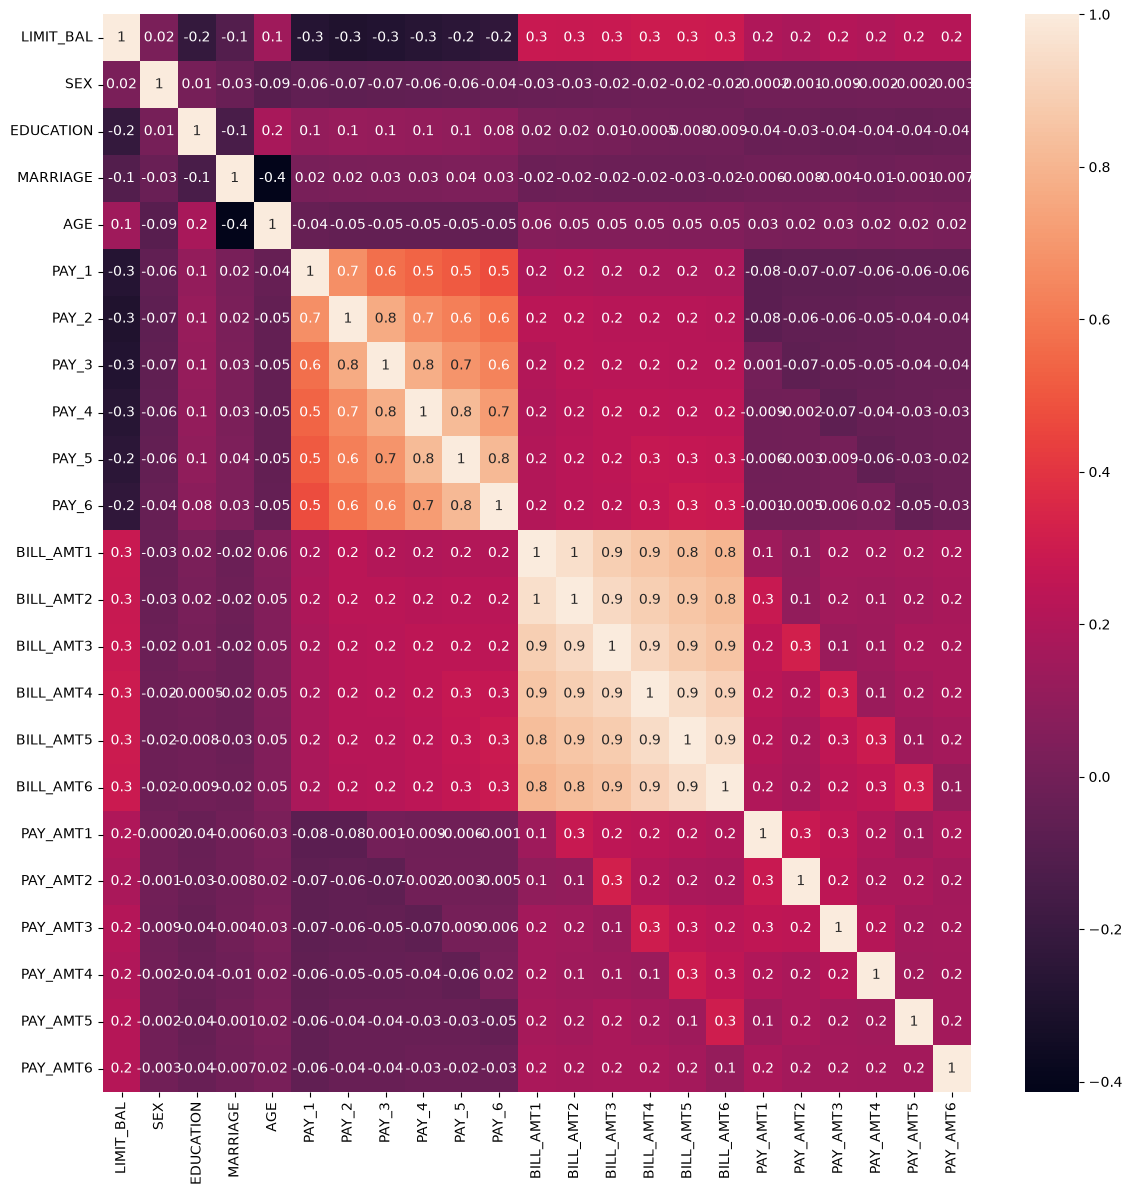

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = X_features.corr() # 피처(컬럼)별 상관계수
plt.figure(figsize=(14,14)) # 차트의 크기
sns.heatmap(corr, annot=True, fmt='.1g')

In [20]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


#BILL_AMT1 ~ BILL_AMT6 까지 6개의 속성명 생성
cols_bill = ['BILL_AMT'+str(i) for i in range(1,7)]
cols_pay = ['PAY_' + str(i) for i in range(1, 7)]
cols_amt = ['PAY_AMT' + str(i) for i in range(1, 7)]
print(cols_bill)
# cols_bill.extend(cols_pay)
# cols_bill.extend(cols_amt)
# print('대상 속성명:',cols_bill)


# 2개의 PCA 속성을 가진 PCA 객체 생성하고, explained_variance_ratio_ 계산 위해 fit( ) 호출
scaler = StandardScaler()
df_cols_scaled = scaler.fit_transform(X_features[cols_bill])
X_features[cols_bill] = X_features[cols_bill].astype("float64")
X_features.loc[:, cols_bill] = df_cols_scaled
pca = PCA(n_components=2)
pca.fit(df_cols_scaled)
print('PCA Component별 변동성:', pca.explained_variance_ratio_)

['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
PCA Component별 변동성: [0.90555253 0.0509867 ]


In [21]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score


rcf = RandomForestClassifier(n_estimators=300, random_state=156)
scores = cross_val_score(rcf, X_features, y_target, scoring='accuracy', cv=3 )


print('CV=3 인 경우의 개별 Fold세트별 정확도:',scores)
print('평균 정확도:{0:.4f}'.format(np.mean(scores)))


CV=3 인 경우의 개별 Fold세트별 정확도: [0.8081 0.8197 0.8232]
평균 정확도:0.8170


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# 원본 데이터셋에 먼저 StandardScaler적용
scaler = StandardScaler()
df_scaled = scaler.fit_transform(X_features)    # 23개의 feature


# 6개의 Component를 가진 PCA 변환을 수행하고 cross_val_score( )로 분류 예측 수행.
pca = PCA(n_components=6)   # 6축으로 줄이겠다.
df_pca = pca.fit_transform(df_scaled)   # pca 수행


scores_pca = cross_val_score(rcf, df_pca, y_target, scoring='accuracy', cv=3)   # 점수 뽑기


print('CV=3 인 경우의 PCA 변환된 개별 Fold세트별 정확도:',scores_pca)
print('PCA 변환 데이터 셋 평균 정확도:{0:.4f}'.format(np.mean(scores_pca)))
 

CV=3 인 경우의 PCA 변환된 개별 Fold세트별 정확도: [0.7913 0.7972 0.802 ]
PCA 변환 데이터 셋 평균 정확도:0.7968
